PART 01: KERNEL BASICS

NOTE: This notebook doesn't aim to produce Havlicek exactly at first.
Its purpose is to understand the quantum kernel idea through a minimal working example.


In [2]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

print("PennyLane:", qml.__version__)

PennyLane: 0.38.0


In [3]:
#Device
n_qubits = 2 #number of qubits / wires in the circuit
dev = qml.device('default.qubit', wires=n_qubits) #statevector simulator backend

#Feature map: quantum circuit that embeds classical input x into a quantum state
#It includes local encoding and an entangling term
def feature_map(x):
    for i in range(n_qubits):
        #local encoding
        qml.Hadamard(wires=i)
        qml.RZ(x[i], wires=i) #single-qubit Z rotation encoding x[i]
    
    #two-qubit feature term: encodes correlation x[0]*x[1] through an entangling sandwich
    qml.CNOT(wires=[0, 1]) #controlled X gate
    qml.RZ(x[0] * x[1], wires=1) #single qubit rotation
    qml.CNOT(wires=[0, 1])
    
#Kernel circuit
@qml.qnode(dev) #this defines quantum node
def kernel_circuit(x1, x2):
    feature_map(x1) #prepare the state |psi(x1)>
    qml.adjoint(feature_map)(x2) #apply U†(x2), undoing the feature map for x2
    return qml.probs(wires=range(n_qubits))  #return probabilities of all computational basis states

#Kernel value -- individual evaluation
def kernel(x1, x2):
    probs = kernel_circuit(x1, x2)
    return probs[0] #probability of measuring |00> state, equal to the kernel overlap

#Test
x1 = np.array([0.1, 0.2]) #2-dimensional input vector, matched to 2-qubit feature map
x2 = np.array([0.1, 0.2])
x3 = np.array([1.0, 2.0])

print("K(x1, x1)", kernel(x1, x1))
print("K(x1, x2)", kernel(x1, x2))
print("K(x1, x3)", kernel(x1, x3))
print("Great!")

K(x1, x1) 0.9999999999999993
K(x1, x2) 0.9999999999999993
K(x1, x3) 0.1754605881434698
Great!


[[1.         0.9950104  0.44461463 0.34395391]
 [0.9950104  1.         0.43855059 0.33839275]
 [0.44461463 0.43855059 1.         0.05329116]
 [0.34395391 0.33839275 0.05329116 1.        ]]
Diagonal: [1. 1. 1. 1.]


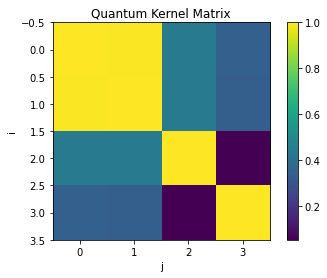

In [53]:
#Building an kernel matrix 
def kernel_matrix(X):
    n = len(X) 
    K = np.zeros([n, n])
    
    for i in range(n):
        for j in range(n):
            K[i,j] = kernel(X[i], X[j])
    return K

#simple dataset
X = np.array([
    [0.1, 0.2],
    [0.2, 0.1],
    [1.0, 1.2],
    [2.0, 2.2]
])

K = kernel_matrix(X)
print(K)
print("Diagonal:", np.diag(K))

#Visualization
plt.imshow(K)
plt.colorbar()
plt.title("Quantum Kernel Matrix")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

Now I remove entanglement to test its role.

[[1.         0.9950104  0.62444239 0.09877488]
 [0.9950104  1.         0.61658157 0.09566347]
 [0.62444239 0.61658157 1.         0.5931328 ]
 [0.09877488 0.09566347 0.5931328  1.        ]]


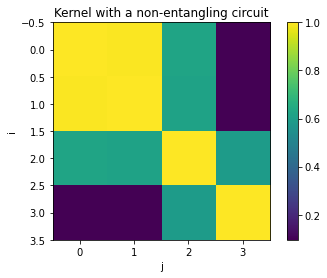

In [56]:
#Let's try circuit with no entanglement
def feature_map(x):
    for i in range(n_qubits):
        #local encoding
        qml.Hadamard(wires=i)
        qml.RZ(x[i], wires=i) 
    
#Kernel circuit
@qml.qnode(dev)
def kernel_circuit(x1, x2):
    feature_map(x1)
    qml.adjoint(feature_map)(x2)
    return qml.probs(wires=range(n_qubits))

#Kernel value
def kernel(x1, x2):
    probs = kernel_circuit(x1, x2)
    return probs[0] 

#Kernel matrix
def kernel_martix(X):
    n = len(X)
    K = np.zeros([n, n])
    for i in range(n):
        for j in range(n):
            K[i,j] = kernel(X[i], X[j])
    return K

K = kernel_matrix(X)
print(K)

#plot
plt.imshow(K)
plt.colorbar()
plt.title("Kernel with a non-entangling circuit")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

Now I increase depth to test expressivity.

[[1.         0.99488182 0.39953017 0.32854049]
 [0.99488182 1.         0.40822858 0.3272428 ]
 [0.39953017 0.40822858 1.         0.48784724]
 [0.32854049 0.3272428  0.48784724 1.        ]]


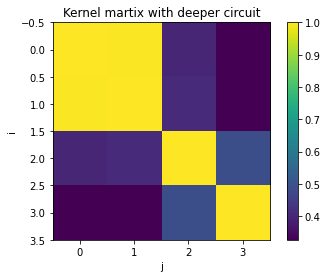

NOTE: When the circuit got deeper the overlap values decreased.
Map became more expressive.


In [58]:
#Trying deeper circuit

#Device
n_qubits = 2
dev = qml.device('default.qubit', wires = n_qubits)

#Feature map deeper
def feature_map_deeper(x):
    for _ in range(2): #layers
        for i in range(n_qubits):
            qml.Hadamard(wires=i)
            qml.RZ(x[i], wires=i)
            
        qml.CNOT(wires=[0,1])
        qml.RZ(x[0]*x[1], wires=1)
        qml.CNOT(wires=[0,1])
        
#Kernel circuit
@qml.qnode(dev)
def kernel_circuit(x1, x2):
    feature_map_deeper(x1)
    qml.adjoint(feature_map_deeper)(x2)
    return qml.probs(wires=range(n_qubits))
    
#Kernel value
def kernel(x1,x2):
    probs = kernel_circuit(x1, x2)
    return probs[0]

#Kernel matrix
def kernel_martix(X):
    n = len(X)
    K = np.zeros([n, n])
    for i in range(n):
        for j in range(n):
            K[i,j] = kernel(X[i], X[j])
    return K

K = kernel_matrix(X)
print(K)

#plot
plt.imshow(K)
plt.colorbar()
plt.title("Kernel martix with deeper circuit")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

#note
print("NOTE: When the circuit got deeper the overlap values decreased.")
print("Map became more expressive.")

Now I intentionally choose a poor map to see failure mode.

[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


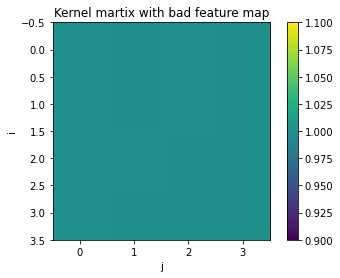

In [55]:
#Let's try some bad feature map example

#Device
n_qubits = 2
dev = qml.device('default.qubit', wires = n_qubits)

#Feature map
def feature_map_bad(x):
    for i in range(n_qubits):
        qml.RZ(x[i], wires=i)

#kernel circuit
@qml.qnode(dev)
def kernel_circuit(x1, x2):
    feature_map_bad(x1)
    qml.adjoint(feature_map_bad)(x2)
    return qml.probs(wires=range(n_qubits))

#Kernel value
def kernel(x1,x2):
    probs = kernel_circuit(x1, x2)
    return probs[0]

#Kernel matrix
def kernel_martix(X):
    n = len(X)
    K = np.zeros([n,n])
    for i in range(n):
        for j in range(n):
            K[i,j] = kernel(X[i], X[j])
    return K

K = kernel_matrix(X)
print(K)

#plot
plt.imshow(K)
plt.colorbar()
plt.title("Kernel martix with bad feature map")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

END OF THIS PART